# Hypothesis 1 — fast agents mainly interact with each other

A minimal agent-based model supporting the LaTeX mathematical modelling.

- `n × n` grid with edges, Moore neighbourhood (8 neighbours)
- Two agent types, fast and slow, half each, placed at random. Types never change.
- Each agent holds an label: `F` (fast-origin information) or `S` (slow-origin). Label is binary. Everyone starts with their own type's label.
- Propagation is defined as when an agent takes a turn it offers its label to all 8 neighbours. Each neighbour independently accepts with probability `p`.
- Speed is defined as: Fast agents take a turn every tick. Slow agents take a turn every `rho` ticks, so `rho = ΔT_s / ΔT_f`.
- Adopt-propagate cycle = one successful adoption event (an offer that was accepted). We count them in a 2×2 table by (propagator type, adopter type).



In [1]:
# Import required libraroes
import numpy as np
import matplotlib.pyplot as plt

FAST, SLOW = 0, 1          # agent type (fixed)
F, S = 0, 1                # information label (changes)


# the 8 Moore-neighbourhood offsets (row shift, column shift)
OFFSETS = [(di, dj) for di in (-1, 0, 1) for dj in (-1, 0, 1) if (di, dj) != (0, 0)]

## 1. Build the grid for the 2D Moore neighbourhood sim

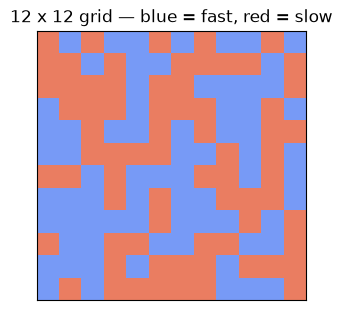

In [2]:
def make_grid(n, rng):
    """n x n grid, half fast / half slow at random. Everyone starts holding their own type's label."""
    kind = np.full(n * n, SLOW, dtype=int)
    kind[: n * n // 2] = FAST
    rng.shuffle(kind)
    kind = kind.reshape(n, n)
    state = np.where(kind == FAST, F, S)
    return kind, state

rng = np.random.default_rng(0) # seeded random number generator for deterministic outcomes
kind, state = make_grid(12, rng)

#plots
plt.figure(figsize=(3.5, 3.5))
plt.imshow(kind, cmap="coolwarm", vmin=-0.3, vmax=1.3)
plt.title("12 x 12 grid — blue = fast agents (AI), red = slow agents (humans)")
plt.xticks([]); plt.yticks([])
plt.show()

## 2. Neighbours without wrap-around

For an offset `(di, dj)`, `src` selects the agents that offer and `dst` selects the neighbours that receive.


In [3]:
def inside(n, di, dj):
    """Slices so that grid[src] offers to grid[dst] for offset (di, dj), staying inside the n x n grid."""
    r0, r1 = max(0, -di), n - max(0, di)
    c0, c1 = max(0, -dj), n - max(0, dj)
    src = (slice(r0, r1), slice(c0, c1))
    dst = (slice(r0 + di, r1 + di), slice(c0 + dj, c1 + dj))
    return src, dst


## 3. One simulation

Each time tick:
1. work out who is active (fast: always; slow: every `rho` ticks, with a random phase so they don't all fire together)
2. every active agent offers its label to all 8 neighbours; each offer is accepted with probability `p`
3. count each accepted offer
4. adopters copy the propagator's label

Step 4 is what makes it an information-spreading model.

In [4]:
def simulate(n, rho, p, slow_steps, seed=0):
    
    rng = np.random.default_rng(seed) # deterministic outputs from seeded rng
    kind, state = make_grid(n, rng)
    phase = rng.integers(0, rho, size=(n, n))
    events = np.zeros((2, 2), dtype=int)

    for t in range(slow_steps * rho):
        active = (kind == FAST) | ((t + phase) % rho == 0)
        new_state = state.copy()
        for di, dj in OFFSETS:
            src, dst = inside(n, di, dj)
            accepted = active[src] & (rng.random(active[src].shape) < p)
            for a in (FAST, SLOW):
                for b in (FAST, SLOW):
                    events[a, b] += np.count_nonzero(accepted & (kind[src] == a) & (kind[dst] == b))
            target = new_state[dst]                  # a view into new_state
            target[accepted] = state[src][accepted]  # adopter copies the propagator's label
        state = new_state
    return events, kind, state

events, kind, state = simulate(n=40, rho=3, p=0.1, slow_steps=5, seed=1)
print("events[propagator, adopter]  (rows: fast, slow / cols: fast, slow)")
print(events)
print()
print(f"share fast->fast        {events[FAST, FAST] / events.sum():.3f}   predicted {3/(2*4):.3f}")
print(f"share started by fast   {events[FAST].sum() / events.sum():.3f}   predicted {3/4:.3f}")
print(f"share received by fast  {events[:, FAST].sum() / events.sum():.3f}   predicted 0.500")

events[propagator, adopter]  (rows: fast, slow / cols: fast, slow)
[[4576 4514]
 [1583 1489]]

share fast->fast        0.376   predicted 0.375
share started by fast   0.747   predicted 0.750
share received by fast  0.506   predicted 0.500


## 4. The 2×2 table at ρ = 3 against the prediction

The grid above has 800+800 agents and ran for 5 slow steps. Prediction is in the LaTeX doc

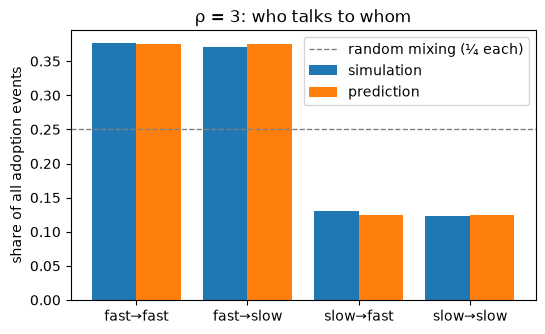

In [5]:
labels = ["fast→fast", "fast→slow", "slow→fast", "slow→slow"]
observed = events.flatten() / events.sum()
predicted3 = np.array([3, 3, 1, 1]) / 8          # 2ρNp : 2ρNp : 2Np : 2Np with ρ = 3

# plots
x = np.arange(4)
plt.figure(figsize=(6, 3.5))
plt.bar(x - 0.2, observed, 0.4, label="simulation")
plt.bar(x + 0.2, predicted3, 0.4, label="prediction")
plt.axhline(0.25, color="grey", linestyle="--", linewidth=1, label="random mixing (¼ each)")
plt.xticks(x, labels)
plt.ylabel("share of all adoption events")
plt.title("ρ = 3: who talks to whom")
plt.legend()
plt.show()

## 5. Sweep the speed ratio ρ ∈ {1, 3, 10, 100}

rho =   1   fast->fast 0.249   started by fast 0.503   received by fast 0.505
rho =   3   fast->fast 0.376   started by fast 0.747   received by fast 0.506
rho =  10   fast->fast 0.454   started by fast 0.908   received by fast 0.501
rho = 100   fast->fast 0.491   started by fast 0.990   received by fast 0.496


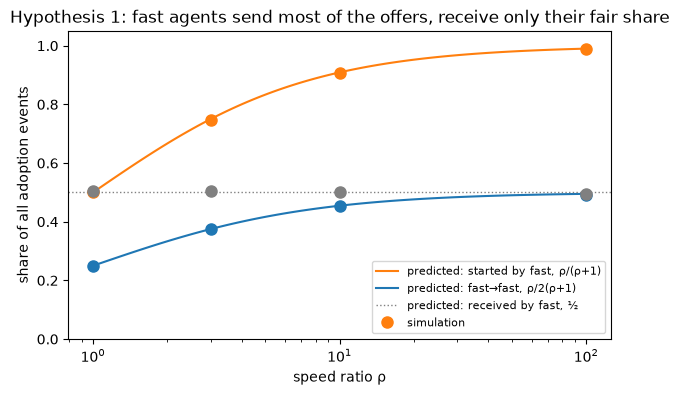

In [6]:
RHOS = [1, 3, 10, 100] # chosen arbitrarily and justified in the blog
ff_share, fast_started, fast_received = [], [], []

for rho in RHOS:
    ev, _, _ = simulate(n=40, rho=rho, p=0.1, slow_steps=5, seed=1)
    tot = ev.sum()
    ff_share.append(ev[FAST, FAST] / tot)
    fast_started.append(ev[FAST].sum() / tot)
    fast_received.append(ev[:, FAST].sum() / tot)
    print(f"rho = {rho:3d}   fast->fast {ff_share[-1]:.3f}   started by fast {fast_started[-1]:.3f}   received by fast {fast_received[-1]:.3f}")
# plots
rho_line = np.logspace(0, 2, 100)
plt.figure(figsize=(7, 4))
plt.plot(rho_line, rho_line / (rho_line + 1), color="C1", label="predicted: started by fast, ρ/(ρ+1)")
plt.plot(rho_line, rho_line / (2 * (rho_line + 1)), color="C0", label="predicted: fast→fast, ρ/2(ρ+1)")
plt.axhline(0.5, color="grey", linestyle=":", linewidth=1, label="predicted: received by fast, ½")
plt.plot(RHOS, fast_started, "o", color="C1", markersize=8, label="simulation")
plt.plot(RHOS, ff_share, "o", color="C0", markersize=8)
plt.plot(RHOS, fast_received, "o", color="grey", markersize=8)
plt.xscale("log")
plt.xlabel("speed ratio ρ")
plt.ylabel("share of all adoption events")
plt.ylim(0, 1.05)
plt.title("Hypothesis 1: fast agents send most of the offers, receive only their fair share")
plt.legend(loc="lower right", fontsize=8)
plt.show()

## 6. Hypothesis 2: fast-origin information drowns out slow-origin information

The blog defines the outcome measure as the share of slow-origin information relative to the share of slow agents using the C-index


In [7]:
def simulate_trace(n, rho, ticks, P, seed):
    
    rng = np.random.default_rng(seed) # deterministic seeded outcome
    kind, state = make_grid(n, rng)
    phase = rng.integers(0, rho, size=(n, n))
    nS = np.empty(ticks + 1, dtype=int)
    nS[0] = np.count_nonzero(state == S)

    for t in range(ticks):
        active = (kind == FAST) | ((t + phase) % rho == 0)
        new_state = state.copy()
        for di, dj in OFFSETS:
            src, dst = inside(n, di, dj)
            prob = P[kind[src], kind[dst]]                # per-pair acceptance probability
            accepted = active[src] & (rng.random(prob.shape) < prob)
            target = new_state[dst]
            target[accepted] = state[src][accepted]
        state = new_state
        nS[t + 1] = np.count_nonzero(state == S)
    return nS


def tau_ticks(rho, p=0.1, k=8, f=0.5):
    """Mixing timescale in units of the fast tick, as in tau"""
    return 1.0 / (k * p * (f + (1 - f) / rho))


N_SIDE, P_SCALAR, SEEDS, T_HORIZON = 40, 0.1, 200, 60
N = N_SIDE ** 2
P_UNIFORM = np.full((2, 2), P_SCALAR)           # P_ff = P_fs = P_sf = P_ss = p
RHOS_C = [1, 2, 3, 5, 10, 30, 100]

print(f"horizon T = {T_HORIZON} ticks, {SEEDS} seeds, {N_SIDE}x{N_SIDE} grid, p = {P_SCALAR}\n")
for rho in RHOS_C:
    print(f"  rho = {rho:3d}   tau = {tau_ticks(rho):.2f} ticks   T/tau = {T_HORIZON / tau_ticks(rho):5.1f}")

horizon T = 60 ticks, 200 seeds, 40x40 grid, p = 0.1

  rho =   1   tau = 1.25 ticks   T/tau =  48.0
  rho =   2   tau = 1.67 ticks   T/tau =  36.0
  rho =   3   tau = 1.88 ticks   T/tau =  32.0
  rho =   5   tau = 2.08 ticks   T/tau =  28.8
  rho =  10   tau = 2.27 ticks   T/tau =  26.4
  rho =  30   tau = 2.42 ticks   T/tau =  24.8
  rho = 100   tau = 2.48 ticks   T/tau =  24.2


### Numerical method proof for the second hypothesis

Run the sweep and look at the fraction of the population holding slow-origin information over time. 

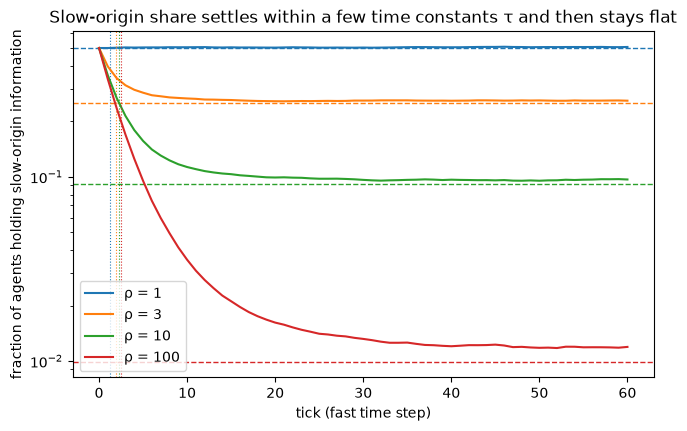

In [8]:
traces = {rho: np.array([simulate_trace(N_SIDE, rho, T_HORIZON, P_UNIFORM, seed)
                         for seed in range(SEEDS)])
          for rho in RHOS_C}


# plots
plt.figure(figsize=(7.5, 4.5))
for i, rho in enumerate([1, 3, 10, 100]):
    mean_frac = traces[rho].mean(axis=0) / N
    plt.plot(mean_frac, color=f"C{i}", label=f"ρ = {rho}")
    plt.axhline(1 / (rho + 1), color=f"C{i}", linestyle="--", linewidth=1)
    plt.axvline(tau_ticks(rho), color=f"C{i}", linestyle=":", linewidth=0.8)
plt.yscale("log")
plt.xlabel("tick (fast time step)")
plt.ylabel("fraction of agents holding slow-origin information")
plt.title("Slow-origin share settles within a few time constants τ and then stays flat")
plt.legend()
plt.show()



---

The cells below continue in the same kernel and re-define a few helpers (`make_grid`, `inside`, `tau_ticks`, `OFFSETS`) with the versions Hypothesis 3 needs, so run the notebook top to bottom.


# Hypothesis 3 — AI agent consulting humans more restores balance

When fast agents are encouraged to consult slow agents more often, slow-origin information can
propagate and compete with fast-origin information. It is a sign of a costly signal.


## 7. Initial Config

These 4 terms are the probabilities associated with adoption-propagation cycle. `P_FF`, `P_FS`, `P_SF`, `P_SS` are the four probabilities under test.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

FAST, SLOW = 0, 1          # agent type (fixed)
F, S = 0, 1                # information label (changes)


P_FF = 0.1     # fast -> fast    
P_FS = 0.1     # fast -> slow    
P_SF = 0.1     # slow -> fast    
P_SS = 0.1     # slow -> slow    

RHO = 3        # speed ratio  dT_s / dT_f

# experiment settings
GRID   = 40    # n x n lattice, half fast / half slow
SEEDS  = 300   # independent runs; C is an expectation over these
N_TAUS = 25    # horizon in units of the mixing time tau  (T >> tau = "appropriately long")
T_MIN, T_MAX = 30, 400
N_JOBS = -1    # joblib parallelism

N = GRID ** 2
OFFSETS = [(di, dj) for di in (-1, 0, 1) for dj in (-1, 0, 1) if (di, dj) != (0, 0)]


def P_matrix(p_ff=P_FF, p_fs=P_FS, p_sf=P_SF, p_ss=P_SS):
    """P[propagator type, adopter type]."""
    return np.array([[p_ff, p_fs],
                     [p_sf, p_ss]], dtype=float)


def C_predicted(rho, P):
    """C = r_s P_sf / (r_f P_fs) = P_sf / (rho P_fs)."""
    return P[SLOW, FAST] / (rho * P[FAST, SLOW])


def tau_ticks(rho, P, k=8, f=0.5):
    """Mixing time in fast ticks: 1 / (k (f r_f P_fs + (1-f) r_s P_sf))."""
    return 1.0 / (k * (f * P[FAST, SLOW] + (1 - f) * (1.0 / rho) * P[SLOW, FAST]))


def horizon(rho, P):
    return int(np.clip(np.ceil(N_TAUS * tau_ticks(rho, P)), T_MIN, T_MAX))




## 8. The model

Same lattice and push dynamics as Hypothesis 1.

In [10]:
def make_grid(n, rng):
    """n x n grid, half fast / half slow at random. Everyone starts holding their own type's label."""
    kind = np.full(n * n, SLOW, dtype=int)
    kind[: n * n // 2] = FAST
    rng.shuffle(kind)
    kind = kind.reshape(n, n)
    return kind, np.where(kind == FAST, F, S)


def inside(n, di, dj):
    """Slices so grid[src] offers to grid[dst] for offset (di, dj), staying inside the grid."""
    r0, r1 = max(0, -di), n - max(0, di)
    c0, c1 = max(0, -dj), n - max(0, dj)
    return ((slice(r0, r1), slice(c0, c1)),
            (slice(r0 + di, r1 + di), slice(c0 + dj, c1 + dj)))


def run(n, rho, ticks, P, seed, sequential=True):
   
    rng = np.random.default_rng(seed)
    kind, state = make_grid(n, rng)
    phase = rng.integers(0, rho, size=(n, n))
    order = list(range(len(OFFSETS)))

    for t in range(ticks):
        active = (kind == FAST) | ((t + phase) % rho == 0)
        if sequential:
            rng.shuffle(order)
            for oi in order:
                di, dj = OFFSETS[oi]
                src, dst = inside(n, di, dj)
                accepted = active[src] & (rng.random(active[src].shape) < P[kind[src], kind[dst]])
                target = state[dst]
                target[accepted] = state[src][accepted]
        else:
            new_state = state.copy()
            for di, dj in OFFSETS:
                src, dst = inside(n, di, dj)
                accepted = active[src] & (rng.random(active[src].shape) < P[kind[src], kind[dst]])
                target = new_state[dst]
                target[accepted] = state[src][accepted]
            state = new_state
    return np.count_nonzero(state == S)


def C_index(rho, P, n=GRID, seeds=SEEDS, sequential=True, boot=2000, rng=None):
    
    T = horizon(rho, P)
    nS = np.array(Parallel(n_jobs=N_JOBS)(
        delayed(run)(n, rho, T, P, s, sequential) for s in range(seeds)), dtype=float)
    Ntot = n * n
    rng = np.random.default_rng(0) if rng is None else rng
    draws = nS[rng.integers(0, nS.size, size=(boot, nS.size))].mean(axis=1)
    lo, hi = np.percentile(draws / (Ntot - draws), [2.5, 97.5])
    return nS.mean() / (Ntot - nS.mean()), lo, hi, T


C, lo, hi, T = C_index(RHO, P_matrix())
print(f"baseline: C = {C:.4f}  95% CI [{lo:.4f}, {hi:.4f}]   "
      f"predicted {C_predicted(RHO, P_matrix()):.4f}   (T = {T} ticks)")

baseline: C = 0.3249  95% CI [0.3129, 0.3372]   predicted 0.3333   (T = 47 ticks)


## 9. Checking the update rule before trusting any of it



In [11]:
def n_fast_label(n, rho, ticks, P, seed, sequential):
    return 1.0 - run(n, rho, ticks, P, seed, sequential) / (n * n)


for rho, p_sf, p_fs in [(3, 0.3, 0.1), (10, 1.0, 0.1), (100, 1.0, 0.01)]:
    P = P_matrix(p_sf=p_sf, p_fs=p_fs)
    row = f"{rho:5d}{p_sf:7.2f}{p_fs:7.3f}   "
    for seq in (False, True):
        vals = np.array(Parallel(n_jobs=N_JOBS)(
            delayed(n_fast_label)(GRID, rho, 30, P, s, seq) for s in range(400)))
        m, se = vals.mean(), vals.std(ddof=1) / np.sqrt(vals.size)
        row += f"{m:.4f}±{se:.4f} ({abs(m - 0.5) / se:4.1f}σ)".rjust(24)
    print(row)



    3   0.30  0.100      0.5112±0.0025 ( 4.5σ)   0.4943±0.0030 ( 1.9σ)
   10   1.00  0.100      0.5212±0.0030 ( 7.1σ)   0.5000±0.0032 ( 0.0σ)
  100   1.00  0.010      0.5298±0.0017 (17.7σ)   0.5022±0.0020 ( 1.1σ)


## 10. Experiment A — sweep the consultation lever $P_{sf}$


 rho   P_sf     T   C observed              95% CI  C predicted  ratio   balance
   1   0.10    32       0.9831   [ 0.954,  1.012]       1.0000   0.98   
   1   0.20    30       2.0386   [ 1.974,  2.109]       2.0000   1.02   C >= 1  <<<
   1   0.30    30       3.0924   [ 2.976,  3.212]       3.0000   1.03   C >= 1  <<<
   1   0.50    30       5.6568   [ 5.391,  5.943]       5.0000   1.13   C >= 1  <<<
   1   0.75    30       8.7895   [ 8.257,  9.350]       7.5000   1.17   C >= 1  <<<
   1   1.00    30      11.5402   [10.838, 12.401]      10.0000   1.15   C >= 1  <<<
   3   0.10    47       0.3249   [ 0.313,  0.337]       0.3333   0.97   
   3   0.20    38       0.6713   [ 0.651,  0.691]       0.6667   1.01   
   3   0.30    32       1.0175   [ 0.990,  1.047]       1.0000   1.02   C >= 1  <<<
   3   0.50    30       1.7594   [ 1.709,  1.812]       1.6667   1.06   C >= 1  <<<
   3   0.75    30       2.6520   [ 2.572,  2.736]       2.5000   1.06   C >= 1  <<<
   3   1.00    30       3.58

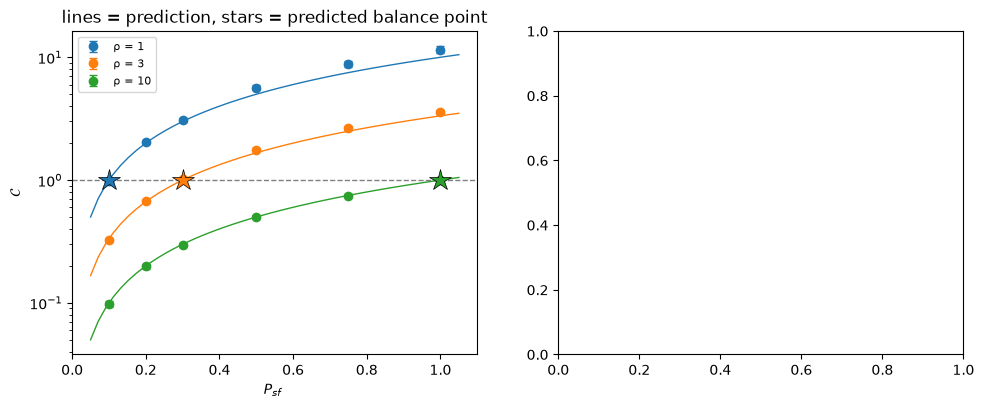

In [12]:
SWEEP_RHOS = [1, 3, 10] # arbitrary sweep
SWEEP_PSF  = [0.1, 0.2, 0.3, 0.5, 0.75, 1.0]

results = {}
print(f"{'rho':>4}{'P_sf':>7}{'T':>6}{'C observed':>13}{'95% CI':>20}{'C predicted':>13}{'ratio':>7}   balance")
for rho in SWEEP_RHOS:
    row = []
    for p_sf in SWEEP_PSF:
        P = P_matrix(p_sf=p_sf)
        C, lo, hi, T = C_index(rho, P)
        row.append((C, lo, hi))
        pred = C_predicted(rho, P)
        print(f"{rho:4d}{p_sf:7.2f}{T:6d}{C:13.4f}   [{lo:6.3f},{hi:7.3f}]{pred:13.4f}"
              f"{C / pred:7.2f}   {'C >= 1  <<<' if C >= 1 else ''}")
    results[rho] = np.array(row)

fig, ax = plt.subplots(1,2, figsize=(11.5, 4.2))
line = np.linspace(0.05, 1.05, 50)
for i, rho in enumerate(SWEEP_RHOS):
    C, lo, hi = results[rho].T
    ax[0].plot(line, line / (rho * P_FS), color=f"C{i}", linewidth=1)
    ax[0].errorbar(SWEEP_PSF, C, yerr=[C - lo, hi - C], fmt="o", color=f"C{i}",
                   capsize=3, label=f"ρ = {rho}")
    ax[0].plot(rho * P_FS, 1.0, marker="*", color=f"C{i}", markersize=16,
               markeredgecolor="k", markeredgewidth=0.5, zorder=5)
ax[0].axhline(1, color="grey", linestyle="--", linewidth=1)
ax[0].set_yscale("log")
ax[0].set_xlabel(r"$P_{sf}$ ")
ax[0].set_ylabel(r"$\mathcal{C}$")
ax[0].set_title("lines = prediction, stars = predicted balance point")
ax[0].legend(fontsize=8)



### 11. Experiment B: Changing both $P_{sf}$ and $P_{fs}$ at once
 
Whichcombinations of the two cross-type probabilities reach $\mathcal{C} \geq 1$?

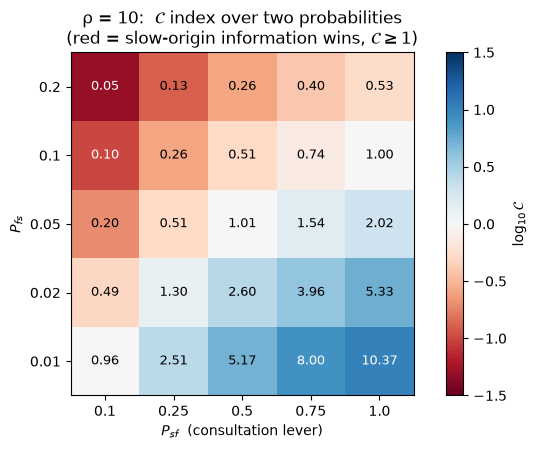

11 of 25 combinations reach C >= 1 at rho = 10.
predicted boundary: P_sf >= rho * P_fs = 10 * P_fs


In [13]:
HEAT_RHO = 10
HEAT_PSF = [0.1, 0.25, 0.5, 0.75, 1.0]
HEAT_PFS = [0.2, 0.1, 0.05, 0.02, 0.01]

heat = np.zeros((len(HEAT_PFS), len(HEAT_PSF)))
for i, p_fs in enumerate(HEAT_PFS):
    for j, p_sf in enumerate(HEAT_PSF):
        heat[i, j] = C_index(HEAT_RHO, P_matrix(p_sf=p_sf, p_fs=p_fs), seeds=150, boot=1)[0]
# plots
plt.figure(figsize=(6.8, 4.6))
plt.imshow(np.log10(heat), cmap="RdBu", vmin=-1.5, vmax=1.5, origin="upper")
plt.colorbar(label=r"$\log_{10} \mathcal{C}$")
for i in range(len(HEAT_PFS)):
    for j in range(len(HEAT_PSF)):
        plt.text(j, i, f"{heat[i, j]:.2f}", ha="center", va="center",
                 fontsize=9, color="k" if abs(np.log10(heat[i, j])) < 0.9 else "w")
plt.xticks(range(len(HEAT_PSF)), HEAT_PSF); plt.yticks(range(len(HEAT_PFS)), HEAT_PFS)
plt.xlabel(r"$P_{sf}$  (consultation lever)"); plt.ylabel(r"$P_{fs}$")
plt.title(f"ρ = {HEAT_RHO}:  $\mathcal{{C}}$ index over two probabilities\n"
          r"(red = slow-origin information wins, $\mathcal{C} \geq 1$)")
plt.tight_layout(); plt.show()

reach = heat >= 1
print(f"{reach.sum()} of {reach.size} combinations reach C >= 1 at rho = {HEAT_RHO}.")
print(f"predicted boundary: P_sf >= rho * P_fs = {HEAT_RHO} * P_fs")